# Driver and constructor circuit performance

This notebook explores how we can separate three parts of a race prediction:

- a driver's performance at a circuit relative to their teammate;
- a constructor's performance at that circuit;
- information that becomes available after qualifying.

The calculations are exploratory. They show what the current race-result data supports and what still needs to be collected before training a model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

SEASON_WEIGHTS = {2023: 0.25, 2024: 0.50, 2025: 0.75, 2026: 1.00}
CIRCUIT_ID = "silverstone"
PRIOR_STRENGTH = 2.0

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    path for path in candidates if (path / "data" / "processed" / "fastf1").exists()
)
data_files = list((PROJECT_ROOT / "data" / "processed" / "fastf1").glob("*/race_results.csv"))
DATA_PATH = max(data_files, key=lambda path: path.parent.name)

results = pd.read_csv(DATA_PATH, parse_dates=["race_date"])
print(f"Loaded {len(results):,} rows from {DATA_PATH.parent.name}")
print(f"Selected circuit: {CIRCUIT_ID}")

Loaded 1,640 rows from 20260810T200317Z
Selected circuit: silverstone


## Target and interpretation

The prediction target is `normalized_position`, a complete order containing every entrant. Classified drivers come first, followed by NC/DNF, DNS and DSQ entries.

Finishing position is affected by the driver, car, circuit and race incidents. Teammate comparisons help control for the car, but they do not make driver ability perfectly independent. Mechanical failures and incidents are kept separate from the pace analysis.

In [2]:
coverage = (
    results.groupby("season")
    .agg(
        races=("race_id", "nunique"),
        rows=("driver_id", "size"),
        drivers=("driver_id", "nunique"),
        constructors=("constructor_id", "nunique"),
        circuits=("circuit_id", "nunique"),
    )
)
status_counts = pd.crosstab(results["season"], results["classification_status"])
required_columns = [
    "race_id", "race_date", "circuit_id", "driver_id",
    "constructor_id", "official_position", "normalized_position",
    "classification_status",
]
missing_required = results[required_columns].isna().sum().rename("missing_values")

display(coverage)
display(status_counts)
display(missing_required.to_frame())

,races,rows,drivers,constructors,circuits
season,,,,,
2023,22,440,22,10,22
2024,24,479,24,10,24
2025,24,479,21,10,24
2026,11,242,22,11,11


classification_status,CLASSIFIED,DNF,DNS,DSQ,NC
season,,,,,
2023,388,46,4,2,0
2024,431,43,3,2,0
2025,424,45,4,6,0
2026,194,39,7,0,2


,missing_values
race_id,0
race_date,0
circuit_id,0
driver_id,0
constructor_id,0
official_position,0
normalized_position,0
classification_status,0


## Comparable performance score

A finishing score puts races with 19, 20 or 22 entrants on the same scale. A winner receives 1 and the last-ranked entrant receives 0. The score is only used for exploration; the final model will still predict a complete order.

In [3]:
results["field_size"] = results.groupby("race_id")["driver_id"].transform("size")
results["finish_score"] = 1 - (
    (results["normalized_position"] - 1) / (results["field_size"] - 1)
)
results["season_weight"] = results["season"].map(SEASON_WEIGHTS)
results["pace_eligible"] = results["classification_status"].eq("CLASSIFIED")
results = results.sort_values(["race_date", "round", "driver_id"]).reset_index(drop=True)
results["prior_race_starts"] = results.groupby("driver_id").cumcount()
results["prior_circuit_starts"] = results.groupby(
    ["driver_id", "circuit_id"]
).cumcount()

reliability = (
    results.assign(
        started=~results["classification_status"].eq("DNS"),
        completed=results["classification_status"].isin(["CLASSIFIED", "NC"]),
    )
    .groupby("season")
    .agg(start_rate=("started", "mean"), completion_rate=("completed", "mean"))
)
display(reliability)

,start_rate,completion_rate
season,,
2023,0.991,0.882
2024,0.994,0.900
2025,0.992,0.885
2026,0.971,0.810


## Driver performance relative to the same car

Only races where both teammates were classified are compared. A positive value means the driver finished ahead of their teammate after adjusting for field size. Recent seasons receive more weight.

In [4]:
classified = results.loc[results["pace_eligible"]].copy()
pair_keys = ["race_id", "constructor_id"]
teammate_pairs = classified.groupby(pair_keys).filter(lambda group: len(group) == 2).copy()
teammate_pairs["teammate_finish_score"] = (
    teammate_pairs.groupby(pair_keys)["finish_score"].transform("sum")
    - teammate_pairs["finish_score"]
)
teammate_pairs["driver_teammate_delta"] = (
    teammate_pairs["finish_score"] - teammate_pairs["teammate_finish_score"]
)
teammate_pairs["weighted_delta"] = (
    teammate_pairs["driver_teammate_delta"] * teammate_pairs["season_weight"]
)

driver_overall = (
    teammate_pairs.groupby(["driver_id", "driver_name"], as_index=False)
    .agg(
        weighted_delta_sum=("weighted_delta", "sum"),
        weight_sum=("season_weight", "sum"),
        teammate_races=("race_id", "nunique"),
    )
)
driver_overall["overall_teammate_score"] = (
    driver_overall["weighted_delta_sum"] / driver_overall["weight_sum"]
)
driver_experience = (
    results.groupby(["driver_id", "driver_name"], as_index=False)
    .agg(
        recorded_race_starts=("race_id", "nunique"),
        recorded_seasons=("season", "nunique"),
        recorded_circuits=("circuit_id", "nunique"),
    )
)
circuit_experience = (
    results.loc[results["circuit_id"].eq(CIRCUIT_ID)]
    .groupby("driver_id", as_index=False)
    .agg(circuit_starts=("race_id", "nunique"))
)
current_drivers = (
    results.loc[results["season"].eq(2026), ["driver_id", "driver_name"]]
    .drop_duplicates()
    .merge(driver_experience, on=["driver_id", "driver_name"], how="left")
    .merge(circuit_experience, on="driver_id", how="left")
)
current_drivers["circuit_starts"] = current_drivers["circuit_starts"].fillna(0).astype(int)
current_driver_summary = (
    current_drivers.merge(
        driver_overall[["driver_id", "overall_teammate_score", "teammate_races"]],
        on="driver_id",
        how="left",
    )
    .sort_values("overall_teammate_score", ascending=False)
)
display(current_driver_summary.reset_index(drop=True))

,driver_id,driver_name,recorded_race_starts,recorded_seasons,recorded_circuits,circuit_starts,overall_teammate_score,teammate_races
0,max_verstappen,Max Verstappen,81,4,24,4,0.294,67
1,alonso,Fernando Alonso,81,4,24,4,0.157,56
2,albon,Alexander Albon,81,4,24,4,0.102,51
3,russell,George Russell,81,4,24,4,0.101,66
4,bearman,Oliver Bearman,38,3,24,2,0.077,31
5,gasly,Pierre Gasly,81,4,24,4,0.076,62
6,hulkenberg,Nico Hülkenberg,81,4,24,4,0.060,60
7,leclerc,Charles Leclerc,81,4,24,4,0.045,68
8,hadjar,Isack Hadjar,35,2,24,2,0.019,26
9,norris,Lando Norris,81,4,24,4,0.015,70


## Circuit-specific driver ranking

Circuit results are sparse because each venue usually appears once per season. The circuit estimate is therefore pulled toward the driver's overall teammate-relative score. Drivers without circuit history use their overall score; drivers without a usable teammate comparison receive a neutral value.

General experience and circuit experience are kept as separate inputs. More starts provide context and confidence, but do not automatically make a driver better. This table uses all completed data for retrospective exploration. When predicting a race, every score and experience count must use only races completed before that event.

In [5]:
driver_circuit = (
    teammate_pairs.groupby(["driver_id", "circuit_id"], as_index=False)
    .agg(
        circuit_delta_sum=("weighted_delta", "sum"),
        circuit_weight_sum=("season_weight", "sum"),
        circuit_pair_races=("race_id", "nunique"),
    )
)
selected_driver_circuit = driver_circuit.loc[driver_circuit["circuit_id"].eq(CIRCUIT_ID)]

driver_circuit_ranking = current_drivers.merge(
    driver_overall[["driver_id", "overall_teammate_score", "teammate_races"]],
    on="driver_id",
    how="left",
).merge(
    selected_driver_circuit.drop(columns="circuit_id"),
    on="driver_id",
    how="left",
)
driver_circuit_ranking["overall_teammate_score"] = (
    driver_circuit_ranking["overall_teammate_score"].fillna(0.0)
)
driver_circuit_ranking["circuit_delta_sum"] = (
    driver_circuit_ranking["circuit_delta_sum"].fillna(0.0)
)
driver_circuit_ranking["circuit_weight_sum"] = (
    driver_circuit_ranking["circuit_weight_sum"].fillna(0.0)
)
driver_circuit_ranking["circuit_pair_races"] = (
    driver_circuit_ranking["circuit_pair_races"].fillna(0).astype(int)
)
driver_circuit_ranking["circuit_driver_score"] = (
    driver_circuit_ranking["circuit_delta_sum"]
    + PRIOR_STRENGTH * driver_circuit_ranking["overall_teammate_score"]
) / (driver_circuit_ranking["circuit_weight_sum"] + PRIOR_STRENGTH)
driver_circuit_ranking = driver_circuit_ranking.sort_values(
    ["circuit_driver_score", "driver_name"], ascending=[False, True]
).reset_index(drop=True)
driver_circuit_ranking["driver_circuit_rank"] = driver_circuit_ranking.index + 1
display(
    driver_circuit_ranking[[
        "driver_circuit_rank", "driver_name", "circuit_driver_score",
        "circuit_pair_races", "circuit_starts", "teammate_races",
        "recorded_race_starts", "recorded_seasons",
    ]]
)

,driver_circuit_rank,driver_name,circuit_driver_score,circuit_pair_races,circuit_starts,teammate_races,recorded_race_starts,recorded_seasons
0,1,Isack Hadjar,0.251,1,2,26,35,2
1,2,George Russell,0.245,2,4,66,81,4
2,3,Max Verstappen,0.162,4,4,67,81,4
3,4,Alexander Albon,0.130,3,4,51,81,4
4,5,Nico Hülkenberg,0.111,1,4,60,81,4
5,6,Lando Norris,0.101,4,4,70,81,4
6,7,Fernando Alonso,0.077,4,4,56,81,4
7,8,Oliver Bearman,0.075,2,2,31,38,3
8,9,Lewis Hamilton,0.065,3,4,68,81,4
9,10,Pierre Gasly,0.035,1,4,62,81,4


## Constructor ranking at the selected circuit

The constructor score averages classified finishes for both cars and applies the same season weights. It is useful as an initial result-based ranking, but it still includes driver-lineup effects and race circumstances. The ranking here is based only on results.

In [6]:
team_race = (
    classified.groupby(
        ["race_id", "season", "circuit_id", "constructor_id", "constructor_name"],
        as_index=False,
    )
    .agg(
        team_finish_score=("finish_score", "mean"),
        classified_drivers=("driver_id", "size"),
        season_weight=("season_weight", "first"),
    )
)
team_race["weighted_team_score"] = (
    team_race["team_finish_score"] * team_race["season_weight"]
)
constructor_overall = (
    team_race.groupby("constructor_id", as_index=False)
    .agg(
        overall_score_sum=("weighted_team_score", "sum"),
        overall_weight_sum=("season_weight", "sum"),
    )
)
constructor_overall["overall_constructor_score"] = (
    constructor_overall["overall_score_sum"] / constructor_overall["overall_weight_sum"]
)
constructor_circuit = (
    team_race.loc[team_race["circuit_id"].eq(CIRCUIT_ID)]
    .groupby("constructor_id", as_index=False)
    .agg(
        circuit_score_sum=("weighted_team_score", "sum"),
        circuit_weight_sum=("season_weight", "sum"),
        circuit_races=("race_id", "nunique"),
    )
)
current_constructors = (
    results.loc[
        results["season"].eq(2026), ["constructor_id", "constructor_name"]
    ].drop_duplicates()
)
constructor_ranking = current_constructors.merge(
    constructor_overall[["constructor_id", "overall_constructor_score"]],
    on="constructor_id", how="left",
).merge(constructor_circuit, on="constructor_id", how="left")
constructor_ranking["circuit_score_sum"] = constructor_ranking["circuit_score_sum"].fillna(0.0)
constructor_ranking["circuit_weight_sum"] = constructor_ranking["circuit_weight_sum"].fillna(0.0)
constructor_ranking["circuit_races"] = constructor_ranking["circuit_races"].fillna(0).astype(int)
constructor_ranking["circuit_constructor_score"] = (
    constructor_ranking["circuit_score_sum"]
    + PRIOR_STRENGTH * constructor_ranking["overall_constructor_score"]
) / (constructor_ranking["circuit_weight_sum"] + PRIOR_STRENGTH)
constructor_ranking = constructor_ranking.sort_values(
    ["circuit_constructor_score", "constructor_name"], ascending=[False, True]
).reset_index(drop=True)
constructor_ranking["constructor_circuit_rank"] = constructor_ranking.index + 1
display(
    constructor_ranking[[
        "constructor_circuit_rank", "constructor_name",
        "circuit_constructor_score", "circuit_races",
    ]]
)

,constructor_circuit_rank,constructor_name,circuit_constructor_score,circuit_races
0,1,McLaren,0.821,4
1,2,Ferrari,0.750,4
2,3,Mercedes,0.730,4
3,4,Red Bull,0.629,4
4,5,Audi,0.576,1
5,6,RB F1 Team,0.545,2
6,7,Alpine F1 Team,0.467,4
7,8,Haas F1 Team,0.442,4
8,9,Aston Martin,0.439,4
9,10,Williams,0.418,4


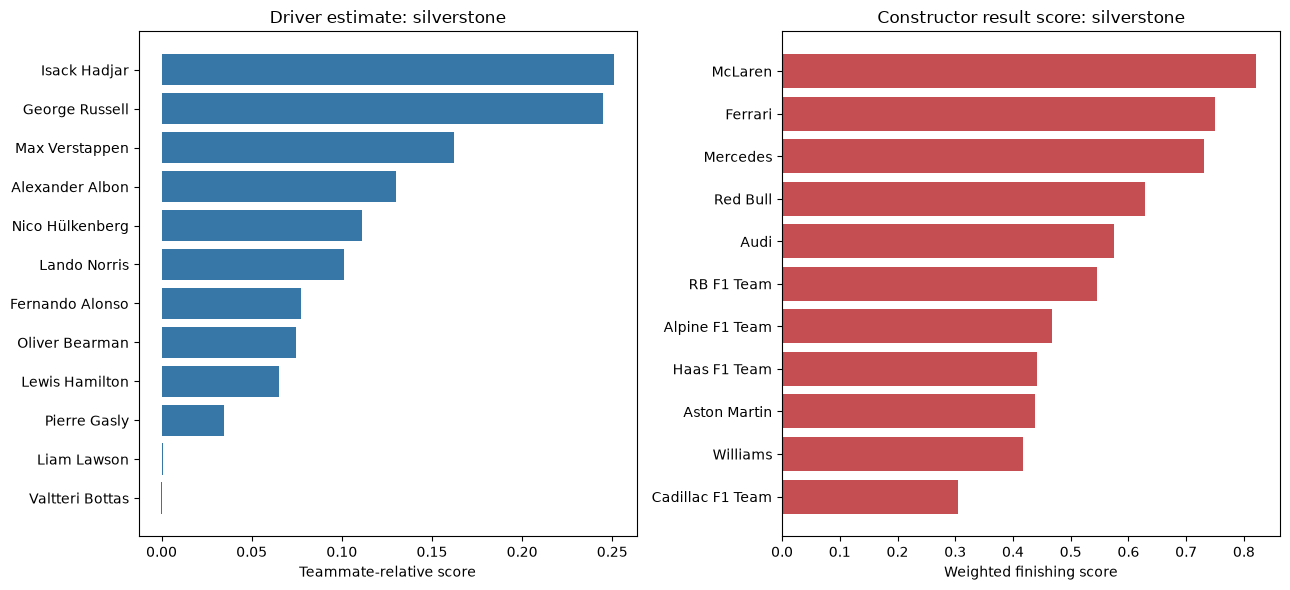

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
driver_plot = driver_circuit_ranking.sort_values("circuit_driver_score").tail(12)
axes[0].barh(driver_plot["driver_name"], driver_plot["circuit_driver_score"], color="#3677a8")
axes[0].set_title(f"Driver estimate: {CIRCUIT_ID}")
axes[0].set_xlabel("Teammate-relative score")
constructor_plot = constructor_ranking.sort_values("circuit_constructor_score")
axes[1].barh(
    constructor_plot["constructor_name"],
    constructor_plot["circuit_constructor_score"],
    color="#c44e52",
)
axes[1].set_title(f"Constructor result score: {CIRCUIT_ID}")
axes[1].set_xlabel("Weighted finishing score")
fig.tight_layout()
plt.show()

## Driver and constructor changes

Stable driver identifiers allow a driver's history to follow them when they change teams. The constructor attached to each result remains the constructor they drove for in that race.

In [8]:
driver_seasons = (
    results.groupby(["driver_id", "driver_name", "season"])["constructor_name"]
    .agg(lambda values: ", ".join(sorted(values.unique())))
    .unstack(fill_value="")
)
changed_teams = driver_seasons.loc[
    driver_seasons.apply(
        lambda row: len({team for team in row if team}) > 1, axis=1
    )
]
display(changed_teams)

,season,2023,2024,2025,2026
driver_id,driver_name,,,,
bearman,Oliver Bearman,,"Ferrari, Haas F1 Team",Haas F1 Team,Haas F1 Team
bortoleto,Gabriel Bortoleto,,,Sauber,Audi
bottas,Valtteri Bottas,Alfa Romeo,Sauber,,Cadillac F1 Team
colapinto,Franco Colapinto,,Williams,Alpine F1 Team,Alpine F1 Team
hadjar,Isack Hadjar,,,RB F1 Team,Red Bull
hamilton,Lewis Hamilton,Mercedes,Mercedes,Ferrari,Ferrari
hulkenberg,Nico Hülkenberg,Haas F1 Team,Haas F1 Team,Sauber,Audi
lawson,Liam Lawson,AlphaTauri,RB F1 Team,"RB F1 Team, Red Bull",RB F1 Team
ocon,Esteban Ocon,Alpine F1 Team,Alpine F1 Team,Haas F1 Team,Haas F1 Team


## How exceptional statuses affect the order

The table below measures where each status appears and, when a driver had a normal grid position, how many positions they lost relative to the grid. It describes the effect on the recorded order; it does not claim where a driver would have finished without the incident.

In [9]:
status_analysis = results.copy()
status_analysis["grid_to_finish_loss"] = (
    status_analysis["normalized_position"] - status_analysis["grid_position"]
).where(status_analysis["grid_position"].gt(0))
status_effect = (
    status_analysis.groupby("classification_status")
    .agg(
        entries=("driver_id", "size"),
        races=("race_id", "nunique"),
        mean_final_position=("normalized_position", "mean"),
        mean_finish_score=("finish_score", "mean"),
        median_laps=("laps_completed", "median"),
        median_grid_to_finish_loss=("grid_to_finish_loss", "median"),
    )
    .sort_values("mean_final_position")
)
race_exception_counts = (
    results.assign(exceptional=~results["classification_status"].eq("CLASSIFIED"))
    .groupby(["race_id", "season"], as_index=False)
    .agg(exceptional_entries=("exceptional", "sum"))
)
exception_frequency = (
    race_exception_counts.groupby("season")
    .agg(
        races=("race_id", "size"),
        races_with_exception=("exceptional_entries", lambda values: values.gt(0).sum()),
        mean_exceptional_entries=("exceptional_entries", "mean"),
        maximum_exceptional_entries=("exceptional_entries", "max"),
    )
)
display(status_effect)
display(exception_frequency)

,entries,races,mean_final_position,mean_finish_score,median_laps,median_grid_to_finish_loss
classification_status,,,,,,
CLASSIFIED,1437,81,9.444,0.561,57.000,-1.000
NC,2,2,17.500,0.214,49.000,-2.500
DNF,173,70,18.948,0.076,20.000,5.000
DSQ,10,6,19.500,0.026,22.000,14.000
DNS,18,13,20.222,0.027,0.000,9.000


,races,races_with_exception,mean_exceptional_entries,maximum_exceptional_entries
season,,,,
2023,22,19,2.364,6
2024,24,20,2.000,5
2025,24,20,2.292,6
2026,11,11,4.364,7


## Does experience relate to performance?

Experience is calculated before each race, so the current result never increases its own experience value. The preferred comparison is teammate-relative performance because raw finishing position is heavily affected by the car. Correlation does not prove that experience caused the result.

In [10]:
experience_sample = teammate_pairs.copy()
experience_sample["general_experience_group"] = pd.cut(
    experience_sample["prior_race_starts"],
    bins=[-1, 9, 29, 59, float("inf")],
    labels=["0-9", "10-29", "30-59", "60+"],
)
experience_sample["circuit_experience_group"] = pd.cut(
    experience_sample["prior_circuit_starts"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["first visit", "1 prior", "2 prior", "3+ prior"],
)
general_experience = (
    experience_sample.groupby("general_experience_group", observed=True)
    .agg(
        comparisons=("driver_id", "size"),
        drivers=("driver_id", "nunique"),
        mean_teammate_delta=("driver_teammate_delta", "mean"),
        mean_finish_score=("finish_score", "mean"),
    )
)
circuit_experience_summary = (
    experience_sample.groupby("circuit_experience_group", observed=True)
    .agg(
        comparisons=("driver_id", "size"),
        drivers=("driver_id", "nunique"),
        mean_teammate_delta=("driver_teammate_delta", "mean"),
        mean_finish_score=("finish_score", "mean"),
    )
)
experience_correlations = pd.Series(
    {
        "general_experience_vs_teammate_delta": experience_sample["prior_race_starts"].corr(
            experience_sample["driver_teammate_delta"], method="spearman"
        ),
        "circuit_experience_vs_teammate_delta": experience_sample["prior_circuit_starts"].corr(
            experience_sample["driver_teammate_delta"], method="spearman"
        ),
        "general_experience_vs_finish_score": experience_sample["prior_race_starts"].corr(
            experience_sample["finish_score"], method="spearman"
        ),
        "circuit_experience_vs_finish_score": experience_sample["prior_circuit_starts"].corr(
            experience_sample["finish_score"], method="spearman"
        ),
    },
    name="spearman_correlation",
)
display(general_experience)
display(circuit_experience_summary)
display(experience_correlations.to_frame())

,comparisons,drivers,mean_teammate_delta,mean_finish_score
general_experience_group,,,,
0-9,229,29,-0.014,0.522
10-29,392,27,-0.005,0.548
30-59,447,25,0.007,0.578
60+,204,14,0.011,0.619


,comparisons,drivers,mean_teammate_delta,mean_finish_score
circuit_experience_group,,,,
first visit,499,29,-0.014,0.536
1 prior,428,26,0.003,0.562
2 prior,259,17,0.017,0.604
3+ prior,86,13,0.016,0.633


,spearman_correlation
general_experience_vs_teammate_delta,0.048
circuit_experience_vs_teammate_delta,0.045
general_experience_vs_finish_score,0.131
circuit_experience_vs_finish_score,0.114


## Are older seasons useful?

Two checks are used. First, driver teammate scores from each season are compared with later seasons. Second, each driver's next teammate comparison is estimated from earlier races only. The proposed season weights are compared with an unweighted history and the most recent 20 usable races.

In [11]:
driver_season_score = (
    teammate_pairs.groupby(["driver_id", "season"])["driver_teammate_delta"]
    .mean()
    .unstack()
)
season_stability_rows = []
for older_season in sorted(SEASON_WEIGHTS):
    for newer_season in sorted(SEASON_WEIGHTS):
        if older_season >= newer_season:
            continue
        shared = driver_season_score[[older_season, newer_season]].dropna()
        season_stability_rows.append(
            {
                "older_season": older_season,
                "newer_season": newer_season,
                "shared_drivers": len(shared),
                "rank_correlation": shared[older_season].rank().corr(
                    shared[newer_season].rank()
                ),
            }
        )
season_stability = pd.DataFrame(season_stability_rows)
display(season_stability)

,older_season,newer_season,shared_drivers,rank_correlation
0,2023,2024,21,0.678
1,2023,2025,15,0.279
2,2023,2026,16,0.094
3,2024,2025,18,0.670
4,2024,2026,18,-0.040
5,2025,2026,19,0.425


In [12]:
history_by_driver = {}
prediction_rows = []
ordered_pairs = teammate_pairs.sort_values(["race_date", "round", "race_id"])
for race_id, race_rows in ordered_pairs.groupby("race_id", sort=False):
    pending_history = []
    for row in race_rows.itertuples():
        history = history_by_driver.get(row.driver_id, [])
        prediction = {
            "race_id": race_id,
            "season": row.season,
            "constructor_id": row.constructor_id,
            "driver_id": row.driver_id,
            "actual_delta": row.driver_teammate_delta,
            "unweighted": float("nan"),
            "proposed_weights": float("nan"),
            "recent_20": float("nan"),
        }
        if history:
            deltas = [item[1] for item in history]
            weights = [SEASON_WEIGHTS[item[0]] for item in history]
            prediction["unweighted"] = sum(deltas) / len(deltas)
            prediction["proposed_weights"] = sum(
                delta * weight for delta, weight in zip(deltas, weights)
            ) / sum(weights)
            recent = deltas[-20:]
            prediction["recent_20"] = sum(recent) / len(recent)
        prediction_rows.append(prediction)
        pending_history.append((row.driver_id, row.season, row.driver_teammate_delta))
    for driver_id, season, delta in pending_history:
        history_by_driver.setdefault(driver_id, []).append((season, delta))

historical_predictions = pd.DataFrame(prediction_rows)
evaluation_sample = historical_predictions.loc[historical_predictions["season"].ge(2024)].copy()
weight_comparison_rows = []
for period_name, period_sample in {
    "2024-2026": evaluation_sample,
    "2026": evaluation_sample.loc[evaluation_sample["season"].eq(2026)],
}.items():
    for method in ["unweighted", "proposed_weights", "recent_20"]:
        usable = period_sample.dropna(subset=[method])
        pair_results = []
        for _, pair in usable.groupby(["race_id", "constructor_id"]):
            if len(pair) != 2:
                continue
            predicted_gap = pair.iloc[0][method] - pair.iloc[1][method]
            actual_gap = pair.iloc[0]["actual_delta"] - pair.iloc[1]["actual_delta"]
            if predicted_gap != 0:
                pair_results.append((predicted_gap > 0) == (actual_gap > 0))
        weight_comparison_rows.append(
            {
                "evaluation_period": period_name,
                "history_method": method,
                "driver_rows": len(usable),
                "mean_absolute_error": (usable[method] - usable["actual_delta"]).abs().mean(),
                "rank_correlation": usable[method].rank().corr(usable["actual_delta"].rank()),
                "teammate_pick_accuracy": sum(pair_results) / len(pair_results),
                "teammate_pairs": len(pair_results),
            }
        )
weight_comparison = pd.DataFrame(weight_comparison_rows)
display(weight_comparison)

,evaluation_period,history_method,driver_rows,mean_absolute_error,rank_correlation,teammate_pick_accuracy,teammate_pairs
0,2024-2026,unweighted,923,0.187,0.351,0.672,458
1,2024-2026,proposed_weights,923,0.185,0.384,0.666,458
2,2024-2026,recent_20,923,0.183,0.400,0.668,458
3,2026,unweighted,157,0.179,0.085,0.603,78
4,2026,proposed_weights,157,0.181,0.091,0.603,78
5,2026,recent_20,157,0.188,0.116,0.603,78


## Decisions from these checks

- Exceptional statuses materially change the order. DNFs lost a median of five places from the grid, while DNS and DSQ entries were normally placed at the bottom. These outcomes should be represented through separate reliability and incident information rather than treated as ordinary driver pace.
- General and circuit experience have weak teammate-adjusted relationships with performance: their rank correlations are about 0.05. They are still useful as low-strength context and confidence features, especially for rookies and sparse circuit histories, but should not dominate ability estimates.
- Recent form transfers better to 2026 than older form. The 2025-to-2026 teammate-score correlation is 0.43, while 2023-to-2026 is 0.09. Older seasons still add history, but need lower influence.
- The proposed season weights slightly improve overall error and rank correlation over an unweighted history, but do not improve every metric or the 2026-only error. Keep `1.00`, `0.75`, `0.50`, and `0.25` as the initial weighted version, and compare it with unweighted and recent-history versions during chronological model evaluation.

## What qualifying adds

Grid position is available in the normalized data and is strongly related to the final result, but it belongs only in a post-qualifying prediction. The pre-weekend prediction must not use the current race's grid or result.

In [13]:
grid_sample = classified.loc[classified["grid_position"].gt(0)].copy()
grid_relationship = (
    grid_sample.groupby("season")
    .apply(
        lambda group: group["grid_position"].rank().corr(
            group["normalized_position"].rank()
        ),
        include_groups=False,
    )
    .rename("grid_finish_rank_correlation")
)
display(grid_relationship.to_frame())

,grid_finish_rank_correlation
season,
2023,0.698
2024,0.791
2025,0.750
2026,0.794


## What the current results tell us

- Grid and finish rank correlations range from about 0.70 to 0.79, so the post-qualifying prediction should be separate and qualifying information should have strong influence.
- Most drivers have no more than four usable teammate comparisons at Silverstone. Hadjar's first-place estimate is based on one circuit comparison, which is evidence of uncertainty rather than proof that he is the strongest driver there.
- The constructor table ranks McLaren highest at Silverstone in the current result-based calculation. It does not separate the car from every driver and race effect.
- Circuit rankings need sample counts and shrinkage beside the score so a small number of races cannot look more certain than it is.

## Information needed for the two prediction points

**Pre-weekend**

- teammate-adjusted driver form using earlier races only;
- general experience from earlier starts and seasons;
- driver history at the circuit, shrunk when the sample is small;
- prior starts at the circuit as a separate experience measure;
- current constructor form and reliability;
- the constructor's earlier results at the circuit.

**Post-qualifying**

- a separate prediction using everything available pre-weekend;
- grid position and qualifying time gaps as high-influence features;
- practice pace, penalties, weather changes and known reliability concerns.

The current dataset does not contain qualifying gaps, practice pace, penalties or weather. The influence of each post-qualifying input must still be measured on later races rather than fixed from the full dataset.

In [14]:
findings = {
    "prediction_target": "normalized_position",
    "driver_signal": "season-weighted teammate comparison plus general and circuit experience",
    "constructor_signal": "season-weighted circuit results, initially separated from reliability",
    "pre_weekend_rule": "use only information available before the event",
    "post_qualifying_addition": "a separate prediction with strong qualifying influence",
    "main_data_gap": "qualifying gaps and other detailed session data",
}
findings

{'prediction_target': 'normalized_position',
 'driver_signal': 'season-weighted teammate comparison plus general and circuit experience',
 'constructor_signal': 'season-weighted circuit results, initially separated from reliability',
 'pre_weekend_rule': 'use only information available before the event',
 'post_qualifying_addition': 'a separate prediction with strong qualifying influence',
 'main_data_gap': 'qualifying gaps and other detailed session data'}